# PU Bagging

Positive Unlabelled Learning is an area of Machine Learning that aims to tackle datasets with samples having: 
1. positive labels
2. no label (could be positive or negative)

This is a situation that can arise in various industries, typically where labelling can be very tedious or expensive. 

The approach we'll take to handle this situation is **PU Bagging**, an algorithm outlined in *Mordelet, F. and Vert J.P. 2010* (https://arxiv.org/abs/1010.0772).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import (
    auc, 
    precision_recall_curve,
    precision_score, 
    recall_score, 
    f1_score
)

## Load Data
Load in the 20 News Groups dataset, and plot the distributions in our target labels.

In [2]:
data_train = fetch_20newsgroups(subset="train")
data_test = fetch_20newsgroups(subset="test")

X_train = data_train.data
y_train = data_train.target
X_test = data_test.data
y_test = data_test.target
target_names = data_train.target_names

In [3]:
def plot_label_frequency(y, target_names, title):
    labels, counts = np.unique(y, return_counts=True)
    class_names = [target_names[i] for i in labels]

    plt.figure(figsize=(12, 6))
    plt.bar(class_names, counts)
    plt.xlabel("Newsgroup")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

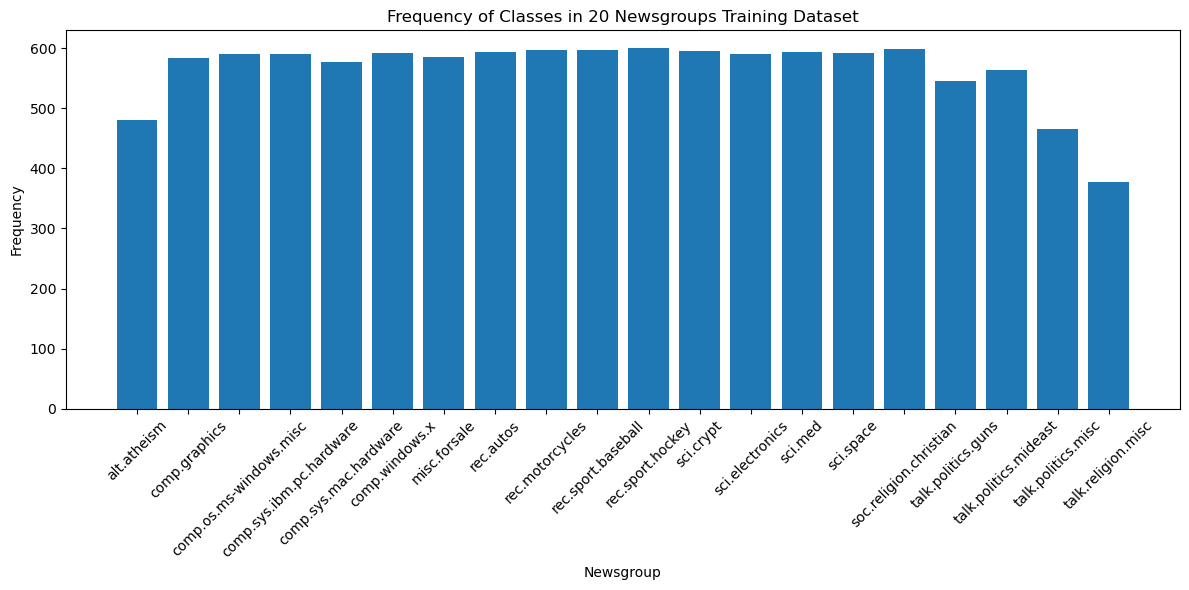

In [4]:
plot_label_frequency(y_train, target_names, "Frequency of Classes in 20 Newsgroups Training Dataset")

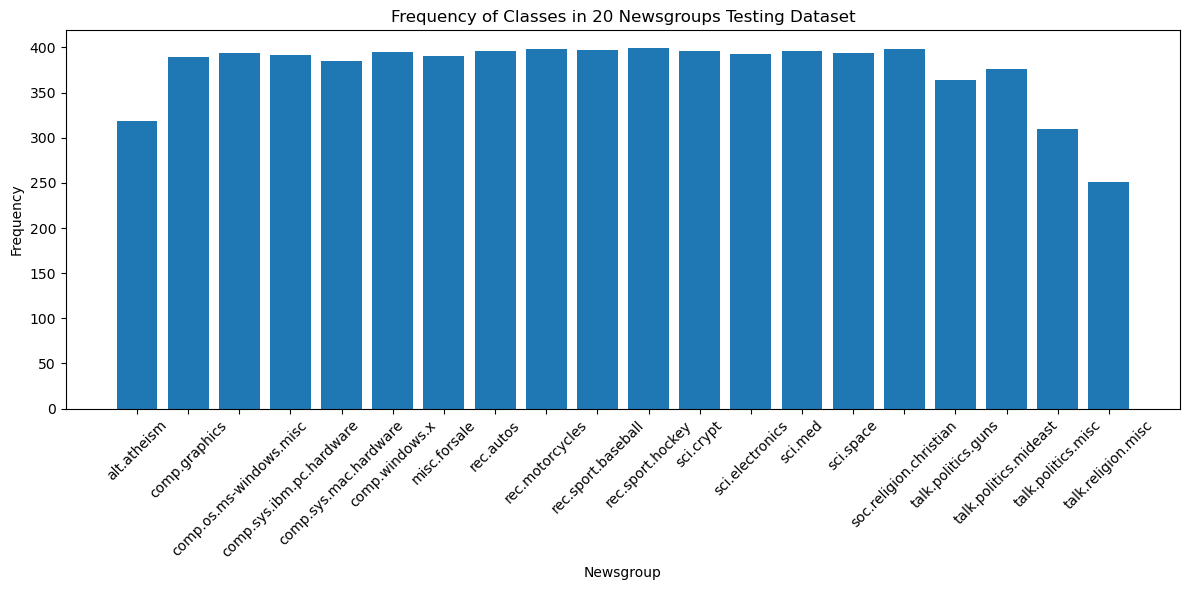

In [5]:
plot_label_frequency(y_test, target_names, "Frequency of Classes in 20 Newsgroups Testing Dataset")

## Preprocessing

In [6]:
preprocessor = TfidfVectorizer(stop_words='english', ngram_range=(1,1))
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
print(f"Number of training samples: {X_train.shape[0]}, number of test samples: {X_test.shape[0]}, number of features created: {X_train.shape[1]}")

Number of training samples: 11314, number of test samples: 7532, number of features created: 129796


## Helper Functions
We'll use these functions below when assessing our models.

In [7]:
def split_idx(y_labels, label) -> tuple:
    positive_idx = np.where(y_labels == label)[0]
    other_idx = np.where(y_labels != label)[0]
    return(positive_idx, other_idx)

def assemble_labels(pos_idx, oth_idx, y_in) -> np.array:
    # create copy
    y = np.copy(y_in)

    # assign label values
    y[pos_idx] = 1
    y[oth_idx] = 0

    return y

def generate_indices(y, g, ratio_hidden_pos) -> tuple:
    # obtain indices for label g
    pos_idx, oth_idx = split_idx(y, g)

    # randomly select some positives to be hidden in the training data
    pos_idx, hidden_pos_idx = train_test_split(
        pos_idx,
        test_size=ratio_hidden_pos,
        random_state=42
    )

    # construct the unlabeled index set:
    #   - all genuinely negative examples
    #   - the hidden positive examples
    unlabeled_idx = np.concatenate([
        oth_idx,
        hidden_pos_idx
    ])

    return(pos_idx, unlabeled_idx)

## Model

In [10]:
model = XGBClassifier(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1)
threshold = 0.5

## Baseline 1

How does our model perform on the completely labelled dataset?

In [11]:
mean_auc, mean_p, mean_r, mean_f = [], [], [], []
# iterate through each label in the data
for g in np.unique(y_train):
    # obtain indices for label g in train set
    pos_train_idx, oth_train_idx = split_idx(y_train, g)

    # set labels equal to g to be 1, otherwise 0
    y_train_g = assemble_labels(pos_train_idx, oth_train_idx, y_train)
    
    # obtain indices for label g in test set
    pos_test_idx, oth_test_idx = split_idx(y_test, g)

    # set labels equal to g to be 1, otherwise 0  
    y_test_g = assemble_labels(pos_test_idx, oth_test_idx, y_test)
    
    # train the model
    model.fit(X_train, y_train_g)

    # evaluate
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba > threshold).astype(int)
    precision, recall, _ = precision_recall_curve(y_test_g, y_proba)
    prauc = auc(recall, precision)
    #auc = roc_auc_score(y_test_g, y_proba)
    p = precision_score(y_test_g, y_pred, pos_label=1)
    r = recall_score(y_test_g, y_pred, pos_label=1)
    f = f1_score(y_test_g, y_pred, pos_label=1)
    print(f"Class {g}:\nPR AUC = {prauc:.2f}, Precision = {p:.2f}, Recall = {r:.2f}, F1 = {f:.2f}")

    # record results
    mean_auc.append(prauc) 
    mean_p.append(p)
    mean_r.append(r)
    mean_f.append(f)

# print mean results
mean_auc = np.mean(mean_auc)
mean_p = np.mean(mean_p)
mean_r = np.mean(mean_r)
mean_f = np.mean(mean_f)
print(f"\nMean PR AUC: {mean_auc:.2f}, Mean Precision: {mean_p:.2f}, Mean Recall: {mean_r:.2f}, Mean F1: {mean_f:.2f}")

Class 0:
PR AUC = 0.74, Precision = 0.80, Recall = 0.52, F1 = 0.63
Class 1:
PR AUC = 0.63, Precision = 0.74, Recall = 0.46, F1 = 0.56
Class 2:
PR AUC = 0.71, Precision = 0.77, Recall = 0.55, F1 = 0.64
Class 3:
PR AUC = 0.57, Precision = 0.73, Recall = 0.39, F1 = 0.51
Class 4:
PR AUC = 0.79, Precision = 0.84, Recall = 0.60, F1 = 0.70
Class 5:
PR AUC = 0.77, Precision = 0.90, Recall = 0.54, F1 = 0.68
Class 6:
PR AUC = 0.85, Precision = 0.87, Recall = 0.72, F1 = 0.78
Class 7:
PR AUC = 0.78, Precision = 0.88, Recall = 0.60, F1 = 0.71
Class 8:
PR AUC = 0.89, Precision = 0.93, Recall = 0.77, F1 = 0.85
Class 9:
PR AUC = 0.86, Precision = 0.94, Recall = 0.61, F1 = 0.74
Class 10:
PR AUC = 0.94, Precision = 0.96, Recall = 0.79, F1 = 0.87
Class 11:
PR AUC = 0.91, Precision = 0.94, Recall = 0.79, F1 = 0.86
Class 12:
PR AUC = 0.50, Precision = 0.79, Recall = 0.23, F1 = 0.36
Class 13:
PR AUC = 0.74, Precision = 0.92, Recall = 0.41, F1 = 0.56
Class 14:
PR AUC = 0.89, Precision = 0.94, Recall = 0.70, 

These results should represent our upper-bound on what we could possibly expect from our PU technique. Now let's assign a portion of the data as "unlabelled", and repeat the analysis done above.

## Baseline 2

Let's now setup the PU-learning scenario. For each newsgroup $g$, we need to extract out a sample from all rows labelled $g$ and keep the remaining rows as *unlabelled*. Then during training, we can take the naive approach and label all unlabelled rows to be negative (0).

In [12]:
positive_labelled = 0.7

In [13]:
mean_auc, mean_p, mean_r, mean_f = [], [], [], []
# iterate through each label in the data
for g in np.unique(y_train):
    # generate indices for PU training dataset
    pos_train_idx, unlabeled_train_idx = generate_indices(y_train, g, 1.0-positive_labelled)

    # create the training labels
    y_train_g = assemble_labels(pos_train_idx, unlabeled_train_idx, y_train)

    # obtain indices for label g in test set
    pos_test_idx, oth_test_idx = split_idx(y_test, g)

    # set test labels equal to g to be 1, otherwise 0  
    y_test_g = assemble_labels(pos_test_idx, oth_test_idx, y_test)
    
    # train the model
    model.fit(X_train, y_train_g)

    # evaluate
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba > threshold).astype(int)
    #auc = roc_auc_score(y_test_g, y_proba)
    precision, recall, _ = precision_recall_curve(y_test_g, y_proba)
    prauc = auc(recall, precision)
    p = precision_score(y_test_g, y_pred, pos_label=1)
    r = recall_score(y_test_g, y_pred, pos_label=1)
    f = f1_score(y_test_g, y_pred, pos_label=1)
    print(f"Class {g}:\nPR AUC = {prauc:.2f}, Precision = {p:.2f}, Recall = {r:.2f}, F1 = {f:.2f}")

    # record results
    mean_auc.append(prauc) 
    mean_p.append(p)
    mean_r.append(r)
    mean_f.append(f)

# print mean results
mean_auc = np.mean(mean_auc)
mean_p = np.mean(mean_p)
mean_r = np.mean(mean_r)
mean_f = np.mean(mean_f)
print(f"\nMean PR AUC: {mean_auc:.2f}, Mean Precision: {mean_p:.2f}, Mean Recall: {mean_r:.2f}, Mean F1: {mean_f:.2f}")

Class 0:
PR AUC = 0.64, Precision = 0.83, Recall = 0.28, F1 = 0.41
Class 1:
PR AUC = 0.58, Precision = 0.78, Recall = 0.29, F1 = 0.42
Class 2:
PR AUC = 0.69, Precision = 0.84, Recall = 0.30, F1 = 0.44
Class 3:
PR AUC = 0.51, Precision = 0.79, Recall = 0.21, F1 = 0.34
Class 4:
PR AUC = 0.71, Precision = 0.87, Recall = 0.39, F1 = 0.54
Class 5:
PR AUC = 0.72, Precision = 0.92, Recall = 0.36, F1 = 0.52
Class 6:
PR AUC = 0.78, Precision = 0.88, Recall = 0.52, F1 = 0.65
Class 7:
PR AUC = 0.74, Precision = 0.93, Recall = 0.35, F1 = 0.51
Class 8:
PR AUC = 0.87, Precision = 0.95, Recall = 0.58, F1 = 0.72
Class 9:
PR AUC = 0.75, Precision = 0.91, Recall = 0.32, F1 = 0.48
Class 10:
PR AUC = 0.89, Precision = 0.97, Recall = 0.56, F1 = 0.71
Class 11:
PR AUC = 0.85, Precision = 0.97, Recall = 0.52, F1 = 0.67
Class 12:
PR AUC = 0.49, Precision = 0.86, Recall = 0.17, F1 = 0.28
Class 13:
PR AUC = 0.69, Precision = 0.98, Recall = 0.23, F1 = 0.37
Class 14:
PR AUC = 0.81, Precision = 0.98, Recall = 0.46, 

The PR AUC drops a bit in comparision with what we saw with Baseline 1, while Precision improved at bit, but Recall has significantly declined (and the F1 score along with it). This indicates that the model struggles more to capture all positive cases in the test set, now that 30% of the positive labels are treated as negatives in the training data.

Let's now compute results using the *PU Bagging* method, and compare the results we the two baselines we can just obtained.

## PU Bagging

Below we will test out <u>Algorithm 1</u> from *Mordelet, F. and Vert J.P. 2010*; an inductive bagging approach to PU learning. This algorithm is defined as follows:

Define: 
* $P$ and $U$ to be the sets of positive labelled and unlabelled data, respectively
* $K$ is the size of the bootstrap samples
* $T$ is the number of bootstrap samples to use

Then:
1. $\text{for} \; t = 1 \; \text{to} \; T \text{:}$
2. $\quad \text{Draw a sample} \; U_t \; \text{of size} \; K \; \text{from} \; U_t$
3. $\quad \text{Train a classifier} \; f_t \; \text{to discriminate} \; P \; \text{from} \; U_t$
4. Compute: $f = \frac{1}{T}\sum_{t=1}^Tf_t$

In [14]:
# set bootstrap parameters
T = 10
K = 600

In [15]:
mean_auc, mean_p, mean_r, mean_f = [], [], [], []
# iterate through each label in the data
for g in np.unique(y_train):

    ### SETUP PU TRAINING DATA ###

    # generate indices for PU training dataset
    pos_train_idx, unlabeled_train_idx = generate_indices(y_train, g, 1.0-positive_labelled)

    # loop over all bootstrap samples
    ensemble = []
    for t in range(T):
        # extract data for boostrap t
        u_idx = np.random.choice(unlabeled_train_idx, size=K, replace=True)
        U_y = np.zeros(u_idx.shape[0])
        P_y = np.ones(pos_train_idx.shape[0])

        # prepare data for training
        x_idx = np.concatenate([u_idx, pos_train_idx])
        X = X_train[x_idx]
        y = np.concatenate([U_y, P_y])

        # train model and store
        model_t = clone(model)
        model_t.fit(X, y)
        ensemble.append(model_t)
    
    ### SETUP TEST DATA ###

    # obtain indices for label g in test set
    pos_test_idx, oth_test_idx = split_idx(y_test, g)

    # set test labels equal to g to be 1, otherwise 0  
    y_test_g = assemble_labels(pos_test_idx, oth_test_idx, y_test)

    ### GENERATE PREDICTIONS & EVALUATE ###
    
    # generate ensemble predictions
    y_proba = 0.0
    for model in ensemble:
        y_proba += model.predict_proba(X_test)[:,1]
    y_proba /= T
    y_pred = (y_proba > threshold).astype(int)
    
    # evaluate
    #auc = roc_auc_score(y_test_g, y_proba)
    precision, recall, _ = precision_recall_curve(y_test_g, y_proba)
    prauc = auc(recall, precision)
    p = precision_score(y_test_g, y_pred, pos_label=1)
    r = recall_score(y_test_g, y_pred, pos_label=1)
    f = f1_score(y_test_g, y_pred, pos_label=1)
    print(f"Class {g}:\nPR AUC = {prauc:.2f}, Precision = {p:.2f}, Recall = {r:.2f}, F1 = {f:.2f}")

    # record results
    mean_auc.append(prauc) 
    mean_p.append(p)
    mean_r.append(r)
    mean_f.append(f)

# print mean results
mean_auc = np.mean(mean_auc)
mean_p = np.mean(mean_p)
mean_r = np.mean(mean_r)
mean_f = np.mean(mean_f)
print(f"\nMean PR AUC: {mean_auc:.2f}, Mean Precision: {mean_p:.2f}, Mean Recall: {mean_r:.2f}, Mean F1: {mean_f:.2f}")

Class 0:
PR AUC = 0.61, Precision = 0.51, Recall = 0.69, F1 = 0.59
Class 1:
PR AUC = 0.60, Precision = 0.39, Recall = 0.73, F1 = 0.51
Class 2:
PR AUC = 0.66, Precision = 0.49, Recall = 0.78, F1 = 0.60
Class 3:
PR AUC = 0.52, Precision = 0.34, Recall = 0.77, F1 = 0.47
Class 4:
PR AUC = 0.70, Precision = 0.50, Recall = 0.80, F1 = 0.61
Class 5:
PR AUC = 0.71, Precision = 0.59, Recall = 0.75, F1 = 0.66
Class 6:
PR AUC = 0.82, Precision = 0.69, Recall = 0.89, F1 = 0.78
Class 7:
PR AUC = 0.71, Precision = 0.65, Recall = 0.73, F1 = 0.69
Class 8:
PR AUC = 0.88, Precision = 0.83, Recall = 0.83, F1 = 0.83
Class 9:
PR AUC = 0.74, Precision = 0.54, Recall = 0.81, F1 = 0.64
Class 10:
PR AUC = 0.91, Precision = 0.78, Recall = 0.88, F1 = 0.83
Class 11:
PR AUC = 0.85, Precision = 0.79, Recall = 0.80, F1 = 0.79
Class 12:
PR AUC = 0.44, Precision = 0.33, Recall = 0.53, F1 = 0.41
Class 13:
PR AUC = 0.71, Precision = 0.67, Recall = 0.65, F1 = 0.66
Class 14:
PR AUC = 0.82, Precision = 0.69, Recall = 0.77, 

## Conclusions

Let's tabulate the results we have obtained:

Model | PR AUC | Precision | Recall | F1
--- | --- | --- | --- | ---
Baseline 1 | 0.76 | 0.85 | 0.57 | 0.67
Baseline 2 | 0.70 | 0.88 | 0.37 | 0.51
PU Bagging | 0.69 | 0.58 | 0.75 | 0.64

For the specific configuration tested here (threshold equal to 0.5, 10 bags, bag size of 600), we can see that the main advantage of PU Bagging comes in terms of *Recall*. In other words, PU Bagging is shown to provide the best means by which to find all positive values in the test set. This comes at the expense of *Precision*, indicating that the the PU Bagging approach does yield more *False Positives* compared to the baselines. 

A more thorough analysis would experiment with trying different values for the following parameters:
* classifier threshold
* number of PU bags
* size of PU bags
* percentage of positives included in the unlabelled dataset
* hyperparameters of the XGBoost model

Diving into this is beyond the scope of this notebook. Feel free to try it out yourself!